# pyspectrum example
In this nootbook the use of PySpectrum is presented
Specifically I show the convolution method for thew peak area and the find peak module

In [1]:
from pyspectrum import Spectrum, germanium_fwhm, FindPeaksDomain, Convolution, TimeChannelParser
from pyspectrum.peak_identification import  asymmetrical_rect_zero_area, gaussian_2_dev
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Find annhilation peak in HPGe

In [2]:
## load spectrum

In [3]:
path = './spectra/time_channel_to_spectrum.txt'
t_c_parser = TimeChannelParser()
energy_calib_poly = np.poly1d([0.0418921521, 0.0653720462])

energy_resolution = 1.08 
estimated_FWHM = lambda energy: germanium_fwhm(energy, 0, energy_resolution/511**0.5, 0)


spectrum  = t_c_parser.to_spectrum(path, energy_calibration_poly=energy_calib_poly, fwhm_calibration=estimated_FWHM,
                                   sep=' ', skiprows=5, num_of_channels=16384,)


In [4]:
# The find peaks method (maybe it should be self contained)
convolution = Convolution(spectrum.fwhm_calibration, gaussian_2_dev)
find_peaks = FindPeaksDomain(spectrum, convolution, n_sigma_threshold=4)
peaks_domain = find_peaks.find_domains_above_snr()

(300.0, 650.0)

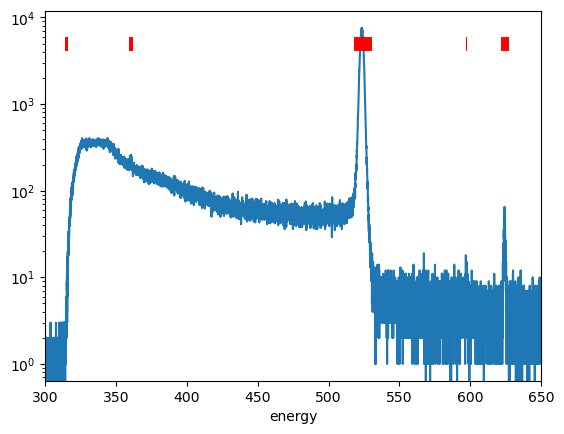

In [5]:
spectrum.xr_spectrum().plot(yscale='log')
for domain in spectrum.energy_calibration(peaks_domain):
    plt.hlines(y=5e3, xmin=domain[0], xmax=domain[1], linestyles='-', colors='red', linewidth=10)
plt.xlim([300,650])

# Some shark fin peak
FindPeaksDomain can be used with different function rather than gaussian
here we use asymmetrical to find asymmetrical peak
however, the example is yet completed due to the auther laziness (and the fact that asymmetrical_rect_zero_area is not define well yet)

In [6]:
# load spectrum
fwhm_calibration = lambda x: 4.3
spec = Spectrum.from_file('./spectra/non_gaussian_peak.txt', energy_calibration_poly=np.poly1d([1, 0]), fwhm_calibration=fwhm_calibration, sep=' ',skiprows=1)

In [7]:
# define the convolution and find peaks
conv  = Convolution(fwhm_calibration, zero_area_function=asymmetrical_rect_zero_area)
find_peaks = FindPeaksDomain(spec, conv, n_sigma_threshold=3.5)

(158, 274)


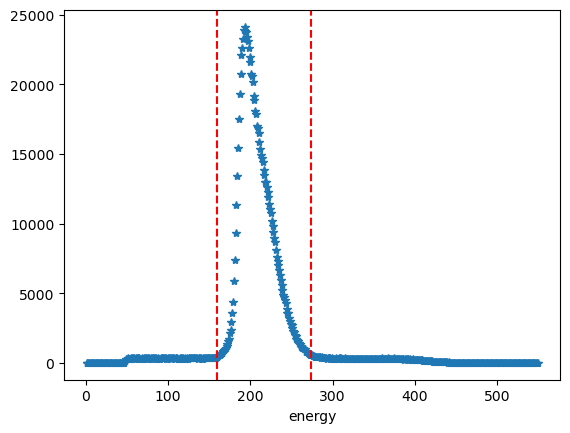

In [9]:
max_index = spec.xr_spectrum().idxmax()
domain = find_peaks.peaks_domain(max_index.item())
# plot result
spec.xr_spectrum().plot(ls='',marker='*')
plt.axvline(x=domain[0]+1, linestyle='--', color='red')
plt.axvline(x=domain[1], linestyle='--', color='red')
print(domain)